# Deep Temporal Models With Attention and Skip Connections for Wheat Futures

---
# 1. Preprocessing

### 1.1 Imports and Global Seed Setup
Setting a global seed ensures reproducibility across all operations.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import itertools, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global seed for reproducible hyperparameter sampling and weight initialization
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [16]:
try:
    # Try local data folder
    fred = pd.read_csv('data/FRED_MD.csv')
    price_train = pd.read_csv('data/wheat_prices_train.csv')
    price_val = pd.read_csv('data/wheat_prices_val.csv')
    price_test = pd.read_csv('data/wheat_prices_test.csv')
except FileNotFoundError:
    # Fallback path
    base_path = 'DeepTemporalModelsWithAttentionAndSkipConnectionsForWheatFutures/data'
    fred = pd.read_csv(f'{base_path}/FRED_MD.csv')
    price_train = pd.read_csv(f'{base_path}/wheat_prices_train.csv')
    price_val = pd.read_csv(f'{base_path}/wheat_prices_val.csv')
    price_test = pd.read_csv(f'{base_path}/wheat_prices_test.csv')

### 1.2 Load FRED-MD Macroeconomic Data
We load the macroeconomic indicators and apply stationarity transformations based on FRED-MD's recommended T-codes.

In [17]:
selected_vars = [
    'RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 
    'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 
    'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 
    'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 
    'PPICMM', 'UMCSENTx'
]
t_codes = fred.iloc[0].drop('sasdate').astype(float).astype(int)
t_codes_selected = t_codes[selected_vars]

# Extract data starting from the second row
fred_data = fred.iloc[1:].copy()
fred_data['sasdate'] = pd.to_datetime(fred_data['sasdate'])
fred_data = fred_data.set_index('sasdate')[selected_vars].astype(float)

# Function to apply stationarity transformations
def apply_transformation(series, t_code):
    if t_code == 1: return series
    elif t_code == 2: return series.diff()
    elif t_code == 3: return series.diff().diff()
    elif t_code == 4: return np.log(series)
    elif t_code == 5: return np.log(series).diff()
    elif t_code == 6: return np.log(series).diff().diff()
    else: return series

# Apply transformations to each column
for col in fred_data.columns:
    fred_data[col] = apply_transformation(fred_data[col], t_codes_selected[col])

# Drop NA rows caused by differencing, and shift by 1 month to avoid lookahead bias
fred_data = fred_data.dropna()
fred_data = fred_data.shift(1).dropna()
print(f"FRED-MD shape after transformation and shift: {fred_data.shape}")

FRED-MD shape after transformation and shift: (571, 31)


### 1.3 Load Daily Wheat Prices & Create Target Variable
We load futures prices and convert them into binary direction targets (1 for UP, 0 for DOWN).

In [ ]:
# We concatenate train, val, and test data for a holistic temporal view
price_df = pd.concat([price_train, price_val, price_test], axis=0).drop_duplicates()

# Clean and standardize date index
price_df['Date'] = pd.to_datetime(price_df['Date'])
price_df = price_df.sort_values('Date').set_index('Date')

# Clean Price strings to floats
price_df['Price'] = price_df['Price'].replace({',': ''}, regex=True).astype(float)

# Create Target: 1 if next day's price > today's price, else 0
price_df['Target'] = (price_df['Price'].shift(-1) > price_df['Price']).astype(int)
price_df = price_df[['Price', 'Target']].copy()
print(f"Wheat price data shape: {price_df.shape}")

Wheat price data shape: (6876, 2)


### 1.4 Merge Macro Data with Daily Prices
We upscale monthly macro data to daily frequency via forward-fill padding and join it with asset prices.

In [19]:
# Upsample monthly data to daily by forward-filling the last known macro state
fred_daily = fred_data.resample('D').ffill()
# Inner join to intersect the available dates
merged_df = price_df.join(fred_daily, how='inner').dropna()
print(f"Merged dataset shape: {merged_df.shape}")

Merged dataset shape: (6790, 33)


### 1.5 Create Temporal Sequences
We slice the merged timeseries into structural Lookback sequences (e.g., 30 days of context) to feed into the recurrent models.

In [20]:
LOOKBACK = 30

def create_sequences(data, target, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(target[i + lookback])
    return np.array(X), np.array(y)

# Separate features from target
features = merged_df.drop('Target', axis=1).values
targets = merged_df['Target'].values

# Generate sequential tensors
X_all, y_all = create_sequences(features, targets, LOOKBACK)
print(f"Total sequences generated: X={X_all.shape}, y={y_all.shape}")

Total sequences generated: X=(6760, 30, 32), y=(6760,)


---
# 2. Common Processes

### 2.1 Activation & Attention Mechanisms
We define the shared non-linearities and the 3 types of attention (Additive, Dot-Product, Multi-Head) used across all 4 recurrent models.

In [21]:
# Helper to dynamically inject non-linearities during hyperparameter search
def get_activation(act_name):
    if act_name == 'relu': return nn.ReLU()
    elif act_name == 'gelu': return nn.GELU()
    elif act_name == 'mish': return nn.Mish()
    return nn.ReLU()

# Additive attention: scores are learned via an MLP layer
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1))
    def forward(self, rnn_out):
        weights = F.softmax(self.attn(rnn_out), dim=1)
        return torch.sum(weights * rnn_out, dim=1)

# Dot-Product attention: scores are derived via Query-Key multiplication
class DotProductAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, rnn_out):
        q = self.query(rnn_out[:, -1, :]).unsqueeze(2)
        k = self.key(rnn_out)
        scores = torch.bmm(k, q).squeeze(2)
        weights = F.softmax(scores, dim=1).unsqueeze(2)
        return torch.sum(weights * rnn_out, dim=1)

# Multi-Head attention: Transformer-style scaled dot-product across multiple subspace paradigms
class MultiHeadAttn(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.mha = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=4, batch_first=True)
    def forward(self, rnn_out):
        attn_out, _ = self.mha(rnn_out, rnn_out, rnn_out)
        return attn_out[:, -1, :]

### 2.2 Skip Connections
We define 3 modes of merging the attention-weighted historical context with the most recent (t=0) macro state.

In [22]:
# Standard depth concatenation
class ConcatSkip(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.map = nn.Linear(input_dim, hidden_dim)
        self.out_dim = hidden_dim * 2
    def forward(self, context, skip_feat):
        return torch.cat([context, self.map(skip_feat)], dim=1)

# Linear algebraic summation 
class AddSkip(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.map = nn.Linear(input_dim, hidden_dim)
        self.out_dim = hidden_dim
    def forward(self, context, skip_feat):
        return context + self.map(skip_feat)

# Learned gating mixture (Highway Network style)
class GatedSkip(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.map = nn.Linear(input_dim, hidden_dim)
        self.gate = nn.Linear(hidden_dim * 2, hidden_dim)
        self.out_dim = hidden_dim
    def forward(self, context, skip_feat):
        skip_mapped = self.map(skip_feat)
        g = torch.sigmoid(self.gate(torch.cat([context, skip_mapped], dim=1)))
        return g * context + (1 - g) * skip_mapped

### 2.3 Common Training & Evaluation Utilities
We define scoring formulas (Accuracy, Precision, Recall, F1) and a visualization module for cross-validation analysis.

In [23]:
# Comprehensive classification metrics calculator
def evaluate_predictions(y_true, y_pred_prob):
    y_pred = (y_pred_prob > 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec_down = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    rec_down = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    prec_up = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec_up = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return y_pred, acc, prec_up, prec_down, rec_up, rec_down, f1, cm

# Diagnostic plotting suite for OOS visualization
def plot_results(all_y_true, all_y_pred, all_y_pred_prob, all_indices, model_name):
    overall_y_pred, acc, prec_up, prec_down, rec_up, rec_down, f1, cm = evaluate_predictions(
        np.array(all_y_true), np.array(all_y_pred_prob))
    
    print(f"\n--- {model_name}: Overall Cross-Validated Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (Up): {prec_up:.4f} | Recall (Up): {rec_up:.4f}")
    print(f"Precision (Down): {prec_down:.4f} | Recall (Down): {rec_down:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{model_name} - Out-of-Sample Performance', fontsize=14, fontweight='bold')
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted (0=Down, 1=Up)')
    axes[0].set_ylabel('Actual (0=Down, 1=Up)')
    
    results_df = pd.DataFrame({'Actual': all_y_true, 'Predicted': all_y_pred}, index=all_indices)
    results_df['Correct'] = (results_df['Actual'] == results_df['Predicted']).astype(int)
    results_df['Rolling_Acc_60D'] = results_df['Correct'].rolling(window=60, min_periods=10).mean()
    
    axes[1].plot(results_df.index, results_df['Rolling_Acc_60D'], color='blue', alpha=0.8, label='60-Day Rolling Accuracy')
    axes[1].axhline(y=0.5, color='red', linestyle='--', label='Random Baseline (50%)')
    axes[1].fill_between(results_df.index, results_df['Rolling_Acc_60D'], 0.5, 
                         where=(results_df['Rolling_Acc_60D'] < 0.5), color='red', alpha=0.3, label='Underperforming Era')
    axes[1].fill_between(results_df.index, results_df['Rolling_Acc_60D'], 0.5, 
                         where=(results_df['Rolling_Acc_60D'] > 0.5), color='green', alpha=0.3, label='Outperforming Era')
    axes[1].set_title('Chronological Model Performance (60-Day Rolling)')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Win Rate (Accuracy)')
    axes[1].legend(loc='lower left')
    plt.tight_layout()
    plt.show()

### 2.4 Tuning Setup and Model-Specific Grids
We define expanded hyperparameters to maximize temporal abstraction while mitigating internal feature co-adaptation.


**Comprehensive Hyperparameter Grid and ML Justifications:**

| Hyperparameter | RNN | BiRNN | LSTM | BiLSTM | Justification |
|---|---|---|---|---|---|
| `hidden_dim` | 64, 96, 128 | 48, 64, 96 | 64, 96, 128 | 48, 64, 96 | Bidirectionality doubles effective dimension; smaller base configs prevent severe overfitting in Bi-models. LSTMs handle depth better via gating. |
| `num_layers` | 1, 2 | 1, 2 | 1, 2, 3 | 1, 2, 3 | Deep vanilla RNNs struggle to converge without gating, hence capped at 2. LSTMs support 3 layers for abstract feature extraction. |
| `dropout` | 0.1, 0.2, 0.3 | 0.2, 0.3, 0.4 | 0.1, 0.2, 0.3 | 0.2, 0.3, 0.4 | Highest parameter models (BiRNN/BiLSTM) require the strongest regularization (up to 40% dropout). |
| `lr` | 1e-3, 2e-3 | 5e-4, 1e-3 | 5e-4, 1e-3, 2e-3 | 5e-4, 1e-3 | Complex loss topologies (Bi-models) require slower, more careful learning rates (e.g. 5e-4) to safely descend ravines. |
| `weight_decay` | 1e-5, 1e-4, 1e-3 | 1e-5, 1e-4, 1e-3 | 1e-5, 1e-4, 1e-3 | 1e-5, 1e-4, 1e-3 | Standard L2 penalty to combat exploding weights and massive feature spaces. |
| `activation` | relu, gelu, mish | relu, gelu, mish | relu, gelu, mish | relu, gelu, mish | Tests standard sparsity (ReLU) vs. state-of-the-art smooth continuous gradients (GELU/Mish) which prevent 'dead' neurons. |
| `patience` | 10, 20, 30 | 10, 20, 30 | 10, 20, 30 | 10, 20, 30 | Allows models with slow learning rates to optionally train longer without arbitrary rigid cutoffs. |


In [24]:
num_tune_samples = int(len(X_all) * 0.8)
X_tune_set = X_all[:num_tune_samples]
y_tune_set = y_all[:num_tune_samples]
tscv_tune = TimeSeriesSplit(n_splits=3)

ATTN_TYPES = ['additive', 'dot', 'multihead']
SKIP_TYPES = ['concat', 'add', 'gated']
N_SAMPLES = 30

rnn_hp = {
    'hidden_dim':   [64, 96, 128],
    'num_layers':   [1, 2],
    'dropout':      [0.1, 0.2, 0.3],
    'lr':           [1e-3, 2e-3],
    'weight_decay': [1e-5, 1e-4, 1e-3],
    'activation':   ['relu', 'gelu', 'mish'],
    'patience':     [10, 20, 30]
}

birnn_hp = {
    'hidden_dim':   [48, 64, 96],
    'num_layers':   [1, 2],
    'dropout':      [0.2, 0.3, 0.4],
    'lr':           [5e-4, 1e-3],
    'weight_decay': [1e-5, 1e-4, 1e-3],
    'activation':   ['relu', 'gelu', 'mish'],
    'patience':     [10, 20, 30]
}

lstm_hp = {
    'hidden_dim':   [64, 96, 128],
    'num_layers':   [1, 2, 3],
    'dropout':      [0.1, 0.2, 0.3],
    'lr':           [5e-4, 1e-3, 2e-3],
    'weight_decay': [1e-5, 1e-4, 1e-3],
    'activation':   ['relu', 'gelu', 'mish'],
    'patience':     [10, 20, 30]
}

bilstm_hp = {
    'hidden_dim':   [48, 64, 96],
    'num_layers':   [1, 2, 3],
    'dropout':      [0.2, 0.3, 0.4],
    'lr':           [5e-4, 1e-3],
    'weight_decay': [1e-5, 1e-4, 1e-3],
    'activation':   ['relu', 'gelu', 'mish'],
    'patience':     [10, 20, 30]
}

for name, hp in [('RNN', rnn_hp), ('BiRNN', birnn_hp), ('LSTM', lstm_hp), ('BiLSTM', bilstm_hp)]:
    grid_size = 1
    for v in hp.values(): grid_size *= len(v)
    grid_size *= len(ATTN_TYPES) * len(SKIP_TYPES)
    print(f"{name}: Search space grid size = {grid_size:,}, sampling {min(N_SAMPLES, grid_size)} combos")
print(f"Tuning set size: {len(X_tune_set)} sequences")

RNN: Search space grid size = 8,748, sampling 30 combos
BiRNN: Search space grid size = 8,748, sampling 30 combos
LSTM: Search space grid size = 19,683, sampling 30 combos
BiLSTM: Search space grid size = 13,122, sampling 30 combos
Tuning set size: 5408 sequences


---
# 3. RNN with Attention and Skip Connection

The unidirectional RNN processes the 30-day input sequence left-to-right, building a hidden state that captures the temporal evolution of macroeconomic conditions.

In [25]:
class RNNAttentionSkip(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2, attn_type="additive", skip_type="concat", activation="relu"):
        super().__init__()
        # Unidirectional RNN to extract features over the 30-day lookback
        # Unidirectional RNN: processes the lookback window left→right,
        # building hidden states that capture sequential macro patterns.
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Choose attention mechanism: additive (MLP-scored) | dot-product
        # (scaled inner product) | multi-head (transformer-style).
        if attn_type == "additive": self.attn = AdditiveAttention(hidden_dim)
        elif attn_type == "dot": self.attn = DotProductAttention(hidden_dim)
        elif attn_type == "multihead": self.attn = MultiHeadAttn(hidden_dim)
            
        # Skip connection merges the attention context with the t=0 raw
        # feature vector to preserve immediate market state signals.
        if skip_type == "concat": self.skip = ConcatSkip(input_dim, hidden_dim)
        elif skip_type == "add": self.skip = AddSkip(input_dim, hidden_dim)
        elif skip_type == "gated": self.skip = GatedSkip(input_dim, hidden_dim)
        
        # Final classifier: LayerNorm → activation → Dropout → sigmoid.
        # Dynamic activation is injected by get_activation() at search time.
        self.fc = nn.Sequential(
            nn.Linear(self.skip.out_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            get_activation(activation),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, seq_len=30, input_features)
        # Pass input sequence through recurrent layer
        out, _ = self.rnn(x)
        # Aggregate temporal features based on learned attention mechanism
        # Compress the full sequence into a single weighted context vector.
        context = self.attn(out)
        # Take the most recent time-step as the skip connection signal.
        skip_feat = x[:, -1, :]
        # Merge attention context with t=0 raw macro state for direct signal propagation
        # Merge attention context with recent raw features.
        combined = self.skip(context, skip_feat)
        return self.fc(combined)

### 3.1 RNN Hyperparameter Tuning (3-Fold TimeSeries CV)

In [26]:
def train_rnn_model(X_train, y_train, X_val, y_val, hidden_dim=128, num_layers=2, dropout=0.3, lr=1e-3, weight_decay=1e-4, patience=20, activation="relu", attn_type="additive", skip_type="concat"):
    train_data = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    val_data = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
    train_loader = DataLoader(train_data, shuffle=False, batch_size=64)
    val_loader = DataLoader(val_data, shuffle=False, batch_size=64)
    
    model = RNNAttentionSkip(input_dim=X_train.shape[2], hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, attn_type=attn_type, skip_type=skip_type, activation=activation)
    criterion = nn.BCELoss()
    # Adam with weight_decay applies L2 regularisation on all weights.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    best_val_loss = float("inf")
    best_model_state = None
    epochs_no_improve = 0
    max_epochs = 100
    
    # ── Training loop ──────────────────────────────────────────────
    # Runs up to max_epochs; exits early when val loss stagnates.
    for epoch in range(max_epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_x).squeeze()
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                preds = model(batch_x).squeeze()
                val_loss += criterion(preds, batch_y).item()
        avg_val_loss = val_loss / len(val_loader)
        
        # Early Stopping: snapshot the best weights when val loss improves.
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            # Increment stagnation counter; stop when it reaches patience.
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
    
    # Restore the best-performing model weights before returning.
    model.load_state_dict(best_model_state)
    return model

print("=== RNN: Starting 3-Fold Hyperparameter Tuning ===")
rnn_keys = ["hidden_dim", "num_layers", "dropout", "lr", "weight_decay", "activation", "patience", "attn_type", "skip_type"]
rnn_grid = list(itertools.product(
    rnn_hp["hidden_dim"], rnn_hp["num_layers"], rnn_hp["dropout"], rnn_hp["lr"], rnn_hp["weight_decay"], rnn_hp["activation"], rnn_hp["patience"],
    ATTN_TYPES, SKIP_TYPES
))
random.seed(SEED)
rnn_sampled = random.sample(rnn_grid, min(N_SAMPLES, len(rnn_grid)))

rnn_best_score = 0
rnn_best_params = {}

for v in rnn_sampled:
    params = dict(zip(rnn_keys, v))
    fold_accs = []
    for train_idx, val_idx in tscv_tune.split(X_tune_set):
        X_tr, X_vl = X_tune_set[train_idx], X_tune_set[val_idx]
        y_tr, y_vl = y_tune_set[train_idx], y_tune_set[val_idx]
        scaler_tune = StandardScaler()
        X_tr_s = scaler_tune.fit_transform(X_tr.reshape(-1, X_tr.shape[2])).reshape(X_tr.shape)
        X_vl_s = scaler_tune.transform(X_vl.reshape(-1, X_vl.shape[2])).reshape(X_vl.shape)
        m = train_rnn_model(X_tr_s, y_tr, X_vl_s, y_vl, **params)
        m.eval()
        with torch.no_grad():
            pp = m(torch.tensor(X_vl_s, dtype=torch.float32)).squeeze().numpy()
        y_pred_vl, acc_fold, _, _, _, _, _, _ = evaluate_predictions(y_vl, pp)
        fold_accs.append(acc_fold)
    avg_acc = np.mean(fold_accs)
    print(f"RNN | Act={params['activation']:<4}, Attn={params['attn_type']:<9}, Skip={params['skip_type']:<6}, Dim={params['hidden_dim']}, L={params['num_layers']}, Drop={params['dropout']}, LR={params['lr']}, WD={params['weight_decay']}, Pat={params['patience']} | 3-Fold Acc: {avg_acc:.4f}")
    if avg_acc > rnn_best_score:
        rnn_best_score = avg_acc
        rnn_best_params = params

print(f"RNN Best 3-Fold Acc: {rnn_best_score:.4f}")
print(f"RNN Best Params: {rnn_best_params}")

=== RNN: Starting 3-Fold Hyperparameter Tuning ===
RNN | Act=gelu, Attn=additive , Skip=gated , Dim=64, L=1, Drop=0.2, LR=0.002, WD=0.0001, Pat=30 | 3-Fold Acc: 0.5096
RNN | Act=relu, Attn=additive , Skip=gated , Dim=96, L=2, Drop=0.1, LR=0.001, WD=1e-05, Pat=20 | 3-Fold Acc: 0.5039
RNN | Act=gelu, Attn=multihead, Skip=concat, Dim=64, L=1, Drop=0.3, LR=0.002, WD=0.001, Pat=30 | 3-Fold Acc: 0.5084
RNN | Act=gelu, Attn=dot      , Skip=concat, Dim=128, L=1, Drop=0.2, LR=0.002, WD=0.0001, Pat=10 | 3-Fold Acc: 0.5047
RNN | Act=mish, Attn=additive , Skip=gated , Dim=96, L=1, Drop=0.3, LR=0.002, WD=0.001, Pat=30 | 3-Fold Acc: 0.4985
RNN | Act=mish, Attn=additive , Skip=concat, Dim=64, L=2, Drop=0.1, LR=0.002, WD=1e-05, Pat=20 | 3-Fold Acc: 0.5047
RNN | Act=mish, Attn=dot      , Skip=add   , Dim=64, L=1, Drop=0.2, LR=0.001, WD=0.0001, Pat=10 | 3-Fold Acc: 0.4995
RNN | Act=mish, Attn=additive , Skip=add   , Dim=128, L=1, Drop=0.1, LR=0.002, WD=0.0001, Pat=10 | 3-Fold Acc: 0.5079
RNN | Act=relu,

### 3.2 RNN 5-Fold Evaluation

=== RNN: Starting 5-Fold Evaluation ===
RNN Fold 1 | Accuracy: 0.5062 | F1: 0.2486
RNN Fold 2 | Accuracy: 0.4956 | F1: 0.2304
RNN Fold 3 | Accuracy: 0.5080 | F1: 0.4851
RNN Fold 4 | Accuracy: 0.5062 | F1: 0.5207
RNN Fold 5 | Accuracy: 0.5187 | F1: 0.4644

--- RNN + Attention + Skip: Overall Cross-Validated Results ---
Accuracy: 0.5069
Precision (Up): 0.4796 | Recall (Up): 0.3620
Precision (Down): 0.5224 | Recall (Down): 0.6398
F1 Score: 0.4126


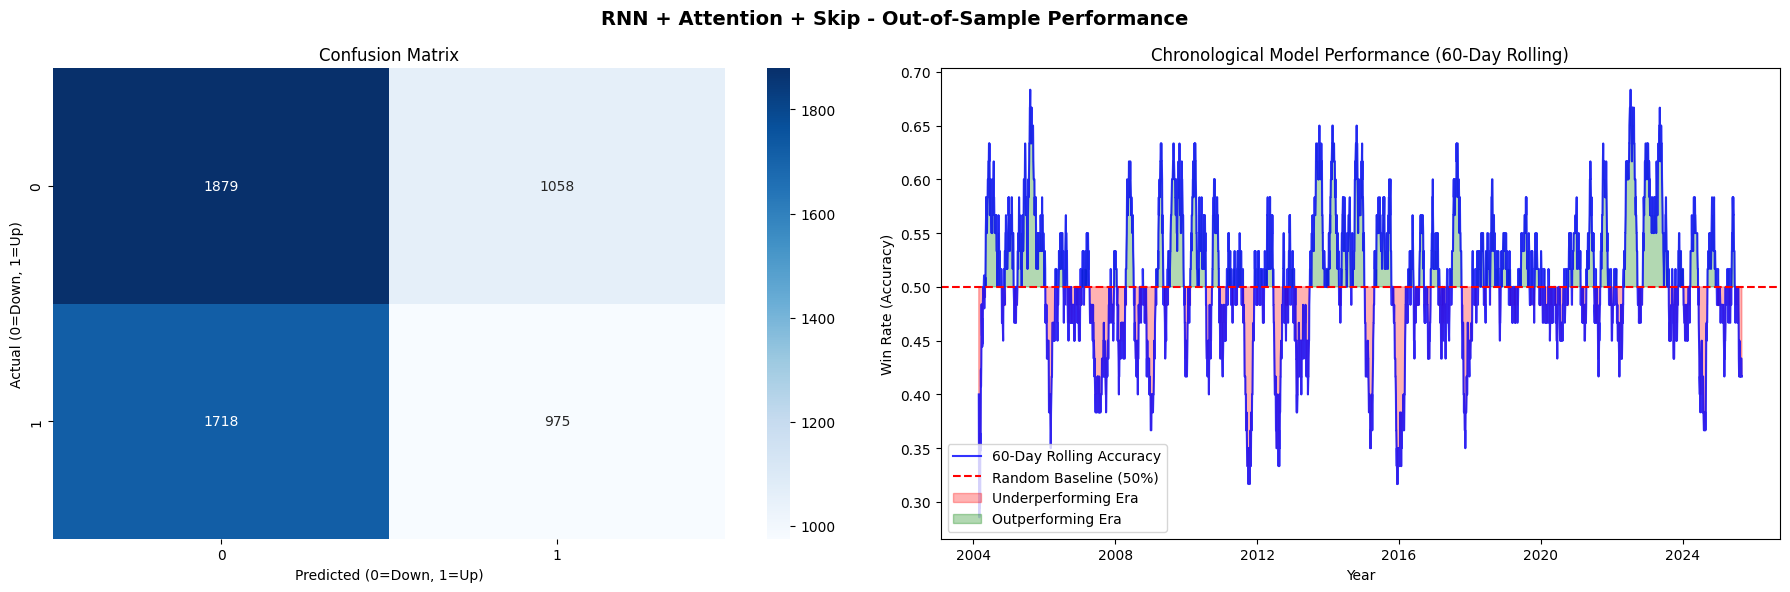

In [27]:
tscv = TimeSeriesSplit(n_splits=5)
rnn_y_true, rnn_y_pred, rnn_y_prob, rnn_indices = [], [], [], []

print("=== RNN: Starting 5-Fold Evaluation ===")
for fold, (train_index, test_index) in enumerate(tscv.split(X_all)):
    X_train_fold, X_test_fold = X_all[train_index], X_all[test_index]
    y_train_fold, y_test_fold = y_all[train_index], y_all[test_index]
    current_indices = merged_df.index[LOOKBACK:][test_index]
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_fold.reshape(-1, X_train_fold.shape[2])).reshape(X_train_fold.shape)
    X_test_s = scaler.transform(X_test_fold.reshape(-1, X_test_fold.shape[2])).reshape(X_test_fold.shape)
    
    model = train_rnn_model(X_train_s, y_train_fold, X_test_s, y_test_fold, **rnn_best_params)
    model.eval()
    with torch.no_grad():
        preds_prob = model(torch.tensor(X_test_s, dtype=torch.float32)).squeeze().numpy()
    y_pred, acc, _, _, _, _, f1, _ = evaluate_predictions(y_test_fold, preds_prob)
    
    rnn_y_true.extend(y_test_fold)
    rnn_y_pred.extend(y_pred)
    rnn_y_prob.extend(preds_prob)
    rnn_indices.extend(current_indices)
    print(f"RNN Fold {fold+1} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

plot_results(rnn_y_true, rnn_y_pred, rnn_y_prob, rnn_indices, "RNN + Attention + Skip")

---
# 4. BiRNN with Attention and Skip Connection

The bidirectional RNN captures macroeconomic dependencies from both past-to-present and present-to-past contexts concurrently, doubling the size of the temporal representation space.

In [28]:
class BiRNNAttentionSkip(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2, attn_type="additive", skip_type="concat", activation="relu"):
        super().__init__()
        # Unidirectional RNN to extract features over the 30-day lookback
        # Unidirectional RNN: processes the lookback window left→right,
        # building hidden states that capture sequential macro patterns.
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        
        bi_dim = hidden_dim * 2
        
        # Choose attention mechanism: additive (MLP-scored) | dot-product
        # (scaled inner product) | multi-head (transformer-style).
        if attn_type == "additive": self.attn = AdditiveAttention(bi_dim)
        elif attn_type == "dot": self.attn = DotProductAttention(bi_dim)
        elif attn_type == "multihead": self.attn = MultiHeadAttn(bi_dim)
            
        # Skip connection merges the attention context with the t=0 raw
        # feature vector to preserve immediate market state signals.
        if skip_type == "concat": self.skip = ConcatSkip(input_dim, bi_dim)
        elif skip_type == "add": self.skip = AddSkip(input_dim, bi_dim)
        elif skip_type == "gated": self.skip = GatedSkip(input_dim, bi_dim)
        
        # Final classifier: LayerNorm → activation → Dropout → sigmoid.
        # Dynamic activation is injected by get_activation() at search time.
        self.fc = nn.Sequential(
            nn.Linear(self.skip.out_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            get_activation(activation),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, seq_len=30, input_features)
        # Pass input sequence through recurrent layer
        out, _ = self.rnn(x)
        # Aggregate temporal features based on learned attention mechanism
        # Compress the full sequence into a single weighted context vector.
        context = self.attn(out)
        # Take the most recent time-step as the skip connection signal.
        skip_feat = x[:, -1, :]
        # Merge attention context with t=0 raw macro state for direct signal propagation
        # Merge attention context with recent raw features.
        combined = self.skip(context, skip_feat)
        return self.fc(combined)

### 4.1 BiRNN Hyperparameter Tuning (3-Fold TimeSeries CV)

In [29]:
def train_birnn_model(X_train, y_train, X_val, y_val, hidden_dim=128, num_layers=2, dropout=0.3, lr=1e-3, weight_decay=1e-4, patience=20, activation="relu", attn_type="additive", skip_type="concat"):
    train_data = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    val_data = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
    train_loader = DataLoader(train_data, shuffle=False, batch_size=64)
    val_loader = DataLoader(val_data, shuffle=False, batch_size=64)
    
    model = BiRNNAttentionSkip(input_dim=X_train.shape[2], hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, attn_type=attn_type, skip_type=skip_type, activation=activation)
    criterion = nn.BCELoss()
    # Adam with weight_decay applies L2 regularisation on all weights.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    best_val_loss = float("inf")
    best_model_state = None
    epochs_no_improve = 0
    max_epochs = 100
    
    # ── Training loop ──────────────────────────────────────────────
    # Runs up to max_epochs; exits early when val loss stagnates.
    for epoch in range(max_epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_x).squeeze()
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                preds = model(batch_x).squeeze()
                val_loss += criterion(preds, batch_y).item()
        avg_val_loss = val_loss / len(val_loader)
        
        # Early Stopping: snapshot the best weights when val loss improves.
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            # Increment stagnation counter; stop when it reaches patience.
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
                
    # Restore the best-performing model weights before returning.
    model.load_state_dict(best_model_state)
    return model

print("=== BiRNN: Starting 3-Fold Hyperparameter Tuning ===")
birnn_keys = ["hidden_dim", "num_layers", "dropout", "lr", "weight_decay", "activation", "patience", "attn_type", "skip_type"]
birnn_grid = list(itertools.product(
    birnn_hp["hidden_dim"], birnn_hp["num_layers"], birnn_hp["dropout"], birnn_hp["lr"], birnn_hp["weight_decay"], birnn_hp["activation"], birnn_hp["patience"],
    ATTN_TYPES, SKIP_TYPES
))
random.seed(SEED)
birnn_sampled = random.sample(birnn_grid, min(N_SAMPLES, len(birnn_grid)))

birnn_best_score = 0
birnn_best_params = {}

for v in birnn_sampled:
    params = dict(zip(birnn_keys, v))
    fold_accs = []
    for train_idx, val_idx in tscv_tune.split(X_tune_set):
        X_tr, X_vl = X_tune_set[train_idx], X_tune_set[val_idx]
        y_tr, y_vl = y_tune_set[train_idx], y_tune_set[val_idx]
        scaler_tune = StandardScaler()
        X_tr_s = scaler_tune.fit_transform(X_tr.reshape(-1, X_tr.shape[2])).reshape(X_tr.shape)
        X_vl_s = scaler_tune.transform(X_vl.reshape(-1, X_vl.shape[2])).reshape(X_vl.shape)
        m = train_birnn_model(X_tr_s, y_tr, X_vl_s, y_vl, **params)
        m.eval()
        with torch.no_grad():
            pp = m(torch.tensor(X_vl_s, dtype=torch.float32)).squeeze().numpy()
        y_pred_vl, acc_fold, _, _, _, _, _, _ = evaluate_predictions(y_vl, pp)
        fold_accs.append(acc_fold)
    avg_acc = np.mean(fold_accs)
    print(f"BiRNN | Act={params['activation']:<4}, Attn={params['attn_type']:<9}, Skip={params['skip_type']:<6}, Dim={params['hidden_dim']}, L={params['num_layers']}, Drop={params['dropout']}, LR={params['lr']}, WD={params['weight_decay']}, Pat={params['patience']} | 3-Fold Acc: {avg_acc:.4f}")
    if avg_acc > birnn_best_score:
        birnn_best_score = avg_acc
        birnn_best_params = params

print(f"BiRNN Best 3-Fold Acc: {birnn_best_score:.4f}")
print(f"BiRNN Best Params: {birnn_best_params}")

=== BiRNN: Starting 3-Fold Hyperparameter Tuning ===
BiRNN | Act=gelu, Attn=additive , Skip=gated , Dim=48, L=1, Drop=0.3, LR=0.001, WD=0.0001, Pat=30 | 3-Fold Acc: 0.5079
BiRNN | Act=relu, Attn=additive , Skip=gated , Dim=64, L=2, Drop=0.2, LR=0.0005, WD=1e-05, Pat=20 | 3-Fold Acc: 0.5084
BiRNN | Act=gelu, Attn=multihead, Skip=concat, Dim=48, L=1, Drop=0.4, LR=0.001, WD=0.001, Pat=30 | 3-Fold Acc: 0.5113
BiRNN | Act=gelu, Attn=dot      , Skip=concat, Dim=96, L=1, Drop=0.3, LR=0.001, WD=0.0001, Pat=10 | 3-Fold Acc: 0.5111
BiRNN | Act=mish, Attn=additive , Skip=gated , Dim=64, L=1, Drop=0.4, LR=0.001, WD=0.001, Pat=30 | 3-Fold Acc: 0.5143
BiRNN | Act=mish, Attn=additive , Skip=concat, Dim=48, L=2, Drop=0.2, LR=0.001, WD=1e-05, Pat=20 | 3-Fold Acc: 0.5076
BiRNN | Act=mish, Attn=dot      , Skip=add   , Dim=48, L=1, Drop=0.3, LR=0.0005, WD=0.0001, Pat=10 | 3-Fold Acc: 0.5042
BiRNN | Act=mish, Attn=additive , Skip=add   , Dim=96, L=1, Drop=0.2, LR=0.001, WD=0.0001, Pat=10 | 3-Fold Acc: 0.50

### 4.2 BiRNN 5-Fold Evaluation

=== BiRNN: Starting 5-Fold Evaluation ===
BiRNN Fold 1 | Accuracy: 0.4947 | F1: 0.1260
BiRNN Fold 2 | Accuracy: 0.4973 | F1: 0.2817
BiRNN Fold 3 | Accuracy: 0.4911 | F1: 0.4377
BiRNN Fold 4 | Accuracy: 0.5293 | F1: 0.3645
BiRNN Fold 5 | Accuracy: 0.5098 | F1: 0.5115

--- BiRNN + Attention + Skip: Overall Cross-Validated Results ---
Accuracy: 0.5044
Precision (Up): 0.4719 | Recall (Up): 0.3030
Precision (Down): 0.5188 | Recall (Down): 0.6891
F1 Score: 0.3691


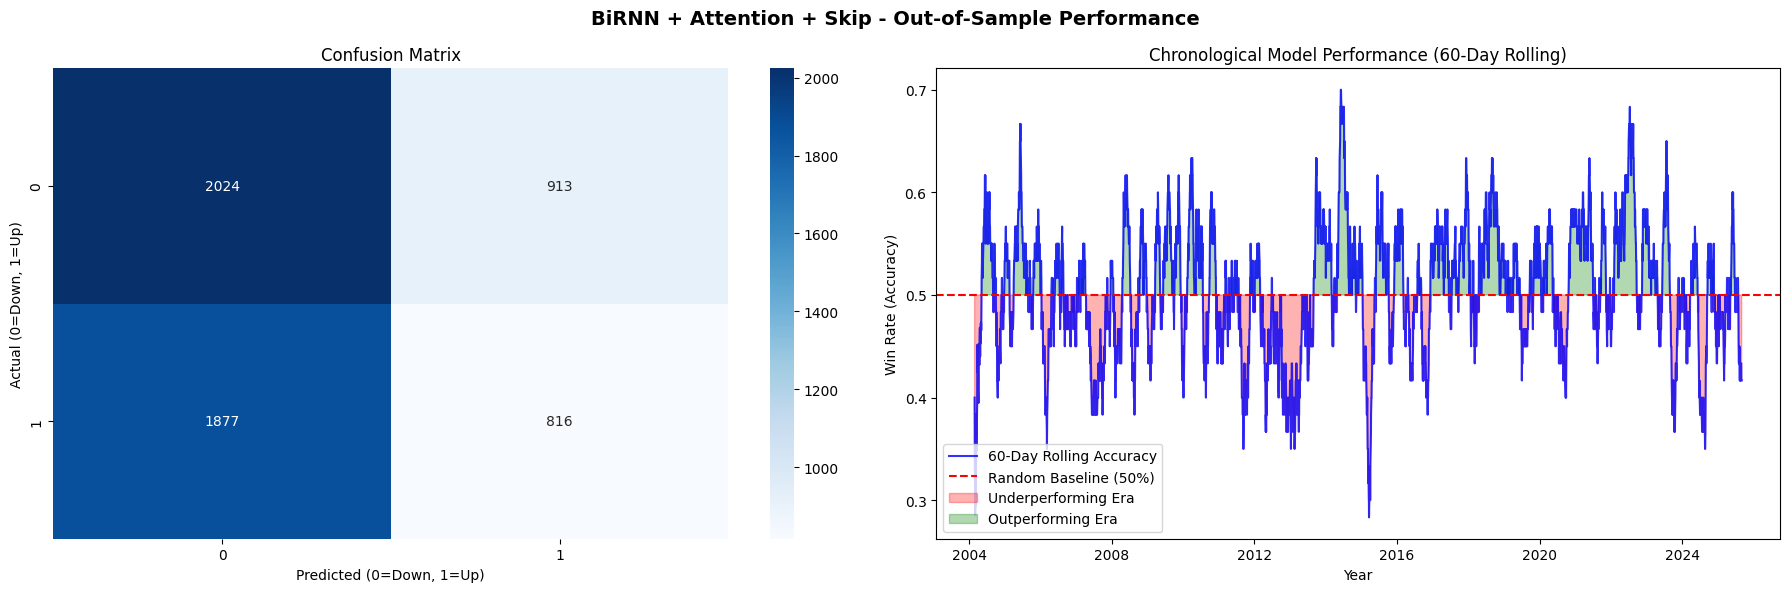

In [30]:
tscv = TimeSeriesSplit(n_splits=5)
birnn_y_true, birnn_y_pred, birnn_y_prob, birnn_indices = [], [], [], []

print("=== BiRNN: Starting 5-Fold Evaluation ===")
for fold, (train_index, test_index) in enumerate(tscv.split(X_all)):
    X_train_fold, X_test_fold = X_all[train_index], X_all[test_index]
    y_train_fold, y_test_fold = y_all[train_index], y_all[test_index]
    current_indices = merged_df.index[LOOKBACK:][test_index]
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_fold.reshape(-1, X_train_fold.shape[2])).reshape(X_train_fold.shape)
    X_test_s = scaler.transform(X_test_fold.reshape(-1, X_test_fold.shape[2])).reshape(X_test_fold.shape)
    
    model = train_birnn_model(X_train_s, y_train_fold, X_test_s, y_test_fold, **birnn_best_params)
    model.eval()
    with torch.no_grad():
        preds_prob = model(torch.tensor(X_test_s, dtype=torch.float32)).squeeze().numpy()
    y_pred, acc, _, _, _, _, f1, _ = evaluate_predictions(y_test_fold, preds_prob)
    
    birnn_y_true.extend(y_test_fold)
    birnn_y_pred.extend(y_pred)
    birnn_y_prob.extend(preds_prob)
    birnn_indices.extend(current_indices)
    print(f"BiRNN Fold {fold+1} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

plot_results(birnn_y_true, birnn_y_pred, birnn_y_prob, birnn_indices, "BiRNN + Attention + Skip")

---
# 5. LSTM with Attention and Skip Connection

The LSTM relies on cell states and gating mechanisms to alleviate vanishing gradients, allowing it to remember very long-term macro dependencies compared to vanilla RNNs.

In [31]:
class LSTMAttentionSkip(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2, attn_type="additive", skip_type="concat", activation="relu"):
        super().__init__()
        # Deep LSTM / BiLSTM layer with gating to mitigate vanishing gradients over long sequences
        # LSTM / BiLSTM: gated recurrent layer that mitigates vanishing
        # gradients via independent cell-state memory.
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Choose attention mechanism: additive (MLP-scored) | dot-product
        # (scaled inner product) | multi-head (transformer-style).
        if attn_type == "additive": self.attn = AdditiveAttention(hidden_dim)
        elif attn_type == "dot": self.attn = DotProductAttention(hidden_dim)
        elif attn_type == "multihead": self.attn = MultiHeadAttn(hidden_dim)
            
        # Skip connection merges the attention context with the t=0 raw
        # feature vector to preserve immediate market state signals.
        if skip_type == "concat": self.skip = ConcatSkip(input_dim, hidden_dim)
        elif skip_type == "add": self.skip = AddSkip(input_dim, hidden_dim)
        elif skip_type == "gated": self.skip = GatedSkip(input_dim, hidden_dim)
        
        # Final classifier: LayerNorm → activation → Dropout → sigmoid.
        # Dynamic activation is injected by get_activation() at search time.
        self.fc = nn.Sequential(
            nn.Linear(self.skip.out_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            get_activation(activation),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, seq_len=30, input_features)
        # Pass input sequence through recurrent layer
        out, (hn, cn) = self.lstm(x)
        # Aggregate temporal features based on learned attention mechanism
        # Compress the full sequence into a single weighted context vector.
        context = self.attn(out)
        # Take the most recent time-step as the skip connection signal.
        skip_feat = x[:, -1, :]
        # Merge attention context with t=0 raw macro state for direct signal propagation
        # Merge attention context with recent raw features.
        combined = self.skip(context, skip_feat)
        return self.fc(combined)

### 5.1 LSTM Hyperparameter Tuning (3-Fold TimeSeries CV)

In [33]:
def train_lstm_model(X_train, y_train, X_val, y_val, hidden_dim=128, num_layers=2, dropout=0.3, lr=1e-3, weight_decay=1e-4, patience=20, activation="relu", attn_type="additive", skip_type="concat"):
    train_data = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    val_data = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
    train_loader = DataLoader(train_data, shuffle=False, batch_size=64)
    val_loader = DataLoader(val_data, shuffle=False, batch_size=64)
    
    model = LSTMAttentionSkip(input_dim=X_train.shape[2], hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, attn_type=attn_type, skip_type=skip_type, activation=activation)
    criterion = nn.BCELoss()
    # Adam with weight_decay applies L2 regularisation on all weights.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    best_val_loss = float("inf")
    best_model_state = None
    epochs_no_improve = 0
    max_epochs = 100
    
    # ── Training loop ──────────────────────────────────────────────
    # Runs up to max_epochs; exits early when val loss stagnates.
    for epoch in range(max_epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_x).squeeze()
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                preds = model(batch_x).squeeze()
                val_loss += criterion(preds, batch_y).item()
        avg_val_loss = val_loss / len(val_loader)
        
        # Early Stopping: snapshot the best weights when val loss improves.
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            # Increment stagnation counter; stop when it reaches patience.
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
                
    # Restore the best-performing model weights before returning.
    model.load_state_dict(best_model_state)
    return model

print("=== LSTM: Starting 3-Fold Hyperparameter Tuning ===")
lstm_keys = ["hidden_dim", "num_layers", "dropout", "lr", "weight_decay", "activation", "patience", "attn_type", "skip_type"]
lstm_grid = list(itertools.product(
    lstm_hp["hidden_dim"], lstm_hp["num_layers"], lstm_hp["dropout"], lstm_hp["lr"], lstm_hp["weight_decay"], lstm_hp["activation"], lstm_hp["patience"],
    ATTN_TYPES, SKIP_TYPES
))
random.seed(SEED)
lstm_sampled = random.sample(lstm_grid, min(N_SAMPLES, len(lstm_grid)))

lstm_best_score = 0
lstm_best_params = {}

for v in lstm_sampled:
    params = dict(zip(lstm_keys, v))
    fold_accs = []
    for train_idx, val_idx in tscv_tune.split(X_tune_set):
        X_tr, X_vl = X_tune_set[train_idx], X_tune_set[val_idx]
        y_tr, y_vl = y_tune_set[train_idx], y_tune_set[val_idx]
        scaler_tune = StandardScaler()
        X_tr_s = scaler_tune.fit_transform(X_tr.reshape(-1, X_tr.shape[2])).reshape(X_tr.shape)
        X_vl_s = scaler_tune.transform(X_vl.reshape(-1, X_vl.shape[2])).reshape(X_vl.shape)
        m = train_lstm_model(X_tr_s, y_tr, X_vl_s, y_vl, **params)
        m.eval()
        with torch.no_grad():
            pp = m(torch.tensor(X_vl_s, dtype=torch.float32)).squeeze().numpy()
        y_pred_vl, acc_fold, _, _, _, _, _, _ = evaluate_predictions(y_vl, pp)
        fold_accs.append(acc_fold)
    avg_acc = np.mean(fold_accs)
    print(f"LSTM  | Act={params['activation']:<4}, Attn={params['attn_type']:<9}, Skip={params['skip_type']:<6}, Dim={params['hidden_dim']}, L={params['num_layers']}, Drop={params['dropout']}, LR={params['lr']}, WD={params['weight_decay']}, Pat={params['patience']} | 3-Fold Acc: {avg_acc:.4f}")
    if avg_acc > lstm_best_score:
        lstm_best_score = avg_acc
        lstm_best_params = params

print(f"LSTM Best 3-Fold Acc: {lstm_best_score:.4f}")
print(f"LSTM Best Params: {lstm_best_params}")

=== LSTM: Starting 3-Fold Hyperparameter Tuning ===
LSTM  | Act=relu, Attn=dot      , Skip=gated , Dim=64, L=1, Drop=0.3, LR=0.001, WD=1e-05, Pat=20 | 3-Fold Acc: 0.5138
LSTM  | Act=relu, Attn=dot      , Skip=gated , Dim=96, L=2, Drop=0.1, LR=0.0005, WD=1e-05, Pat=30 | 3-Fold Acc: 0.5101
LSTM  | Act=relu, Attn=dot      , Skip=concat, Dim=64, L=2, Drop=0.1, LR=0.002, WD=0.001, Pat=30 | 3-Fold Acc: 0.5123
LSTM  | Act=mish, Attn=multihead, Skip=concat, Dim=128, L=1, Drop=0.1, LR=0.0005, WD=0.001, Pat=10 | 3-Fold Acc: 0.5042
LSTM  | Act=mish, Attn=dot      , Skip=add   , Dim=96, L=1, Drop=0.3, LR=0.002, WD=0.001, Pat=20 | 3-Fold Acc: 0.5017
LSTM  | Act=gelu, Attn=additive , Skip=add   , Dim=64, L=2, Drop=0.2, LR=0.002, WD=0.0001, Pat=30 | 3-Fold Acc: 0.5037
LSTM  | Act=gelu, Attn=multihead, Skip=gated , Dim=64, L=1, Drop=0.2, LR=0.002, WD=1e-05, Pat=10 | 3-Fold Acc: 0.5197
LSTM  | Act=gelu, Attn=dot      , Skip=concat, Dim=96, L=3, Drop=0.3, LR=0.0005, WD=1e-05, Pat=10 | 3-Fold Acc: 0.5104

### 5.2 LSTM 5-Fold Evaluation

=== LSTM: Starting 5-Fold Evaluation ===
LSTM Fold 1 | Accuracy: 0.4929 | F1: 0.1229
LSTM Fold 2 | Accuracy: 0.5053 | F1: 0.3978
LSTM Fold 3 | Accuracy: 0.5062 | F1: 0.2962
LSTM Fold 4 | Accuracy: 0.4973 | F1: 0.5706
LSTM Fold 5 | Accuracy: 0.5187 | F1: 0.3668

--- LSTM + Attention + Skip: Overall Cross-Validated Results ---
Accuracy: 0.5041
Precision (Up): 0.4732 | Recall (Up): 0.3245
Precision (Down): 0.5192 | Recall (Down): 0.6687
F1 Score: 0.3850


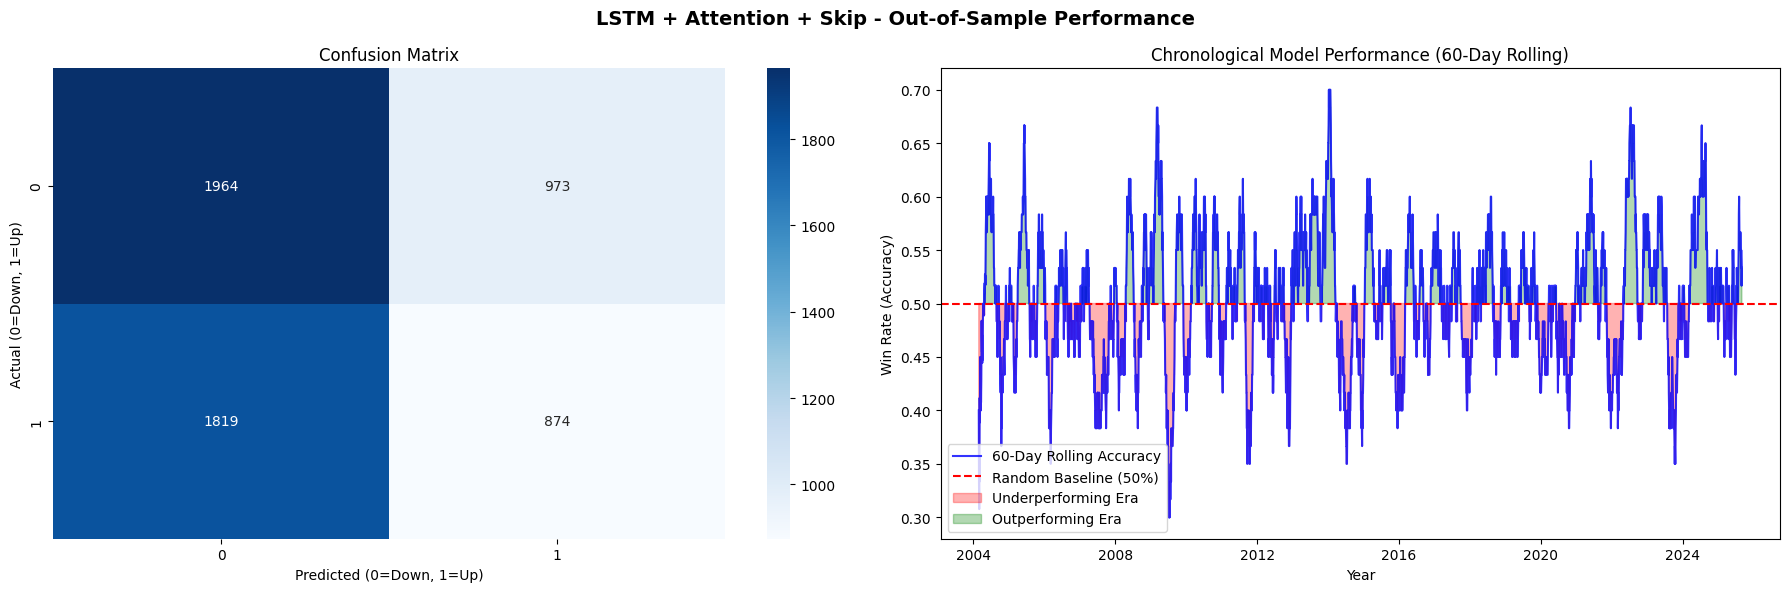

In [34]:
tscv = TimeSeriesSplit(n_splits=5)
lstm_y_true, lstm_y_pred, lstm_y_prob, lstm_indices = [], [], [], []

print("=== LSTM: Starting 5-Fold Evaluation ===")
for fold, (train_index, test_index) in enumerate(tscv.split(X_all)):
    X_train_fold, X_test_fold = X_all[train_index], X_all[test_index]
    y_train_fold, y_test_fold = y_all[train_index], y_all[test_index]
    current_indices = merged_df.index[LOOKBACK:][test_index]
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_fold.reshape(-1, X_train_fold.shape[2])).reshape(X_train_fold.shape)
    X_test_s = scaler.transform(X_test_fold.reshape(-1, X_test_fold.shape[2])).reshape(X_test_fold.shape)
    
    model = train_lstm_model(X_train_s, y_train_fold, X_test_s, y_test_fold, **lstm_best_params)
    model.eval()
    with torch.no_grad():
        preds_prob = model(torch.tensor(X_test_s, dtype=torch.float32)).squeeze().numpy()
    y_pred, acc, _, _, _, _, f1, _ = evaluate_predictions(y_test_fold, preds_prob)
    
    lstm_y_true.extend(y_test_fold)
    lstm_y_pred.extend(y_pred)
    lstm_y_prob.extend(preds_prob)
    lstm_indices.extend(current_indices)
    print(f"LSTM Fold {fold+1} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

plot_results(lstm_y_true, lstm_y_pred, lstm_y_prob, lstm_indices, "LSTM + Attention + Skip")

---
# 6. BiLSTM with Attention and Skip Connection

The BiLSTM is the most complex model in the suite, leveraging both forward and backward temporal gating architectures to construct a highly context-aware macro representation.

In [35]:
class BiLSTMAttentionSkip(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2, attn_type="additive", skip_type="concat", activation="relu"):
        super().__init__()
        # Deep LSTM / BiLSTM layer with gating to mitigate vanishing gradients over long sequences
        # LSTM / BiLSTM: gated recurrent layer that mitigates vanishing
        # gradients via independent cell-state memory.
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        
        bi_dim = hidden_dim * 2  
        
        # Choose attention mechanism: additive (MLP-scored) | dot-product
        # (scaled inner product) | multi-head (transformer-style).
        if attn_type == "additive": self.attn = AdditiveAttention(bi_dim)
        elif attn_type == "dot": self.attn = DotProductAttention(bi_dim)
        elif attn_type == "multihead": self.attn = MultiHeadAttn(bi_dim)
            
        # Skip connection merges the attention context with the t=0 raw
        # feature vector to preserve immediate market state signals.
        if skip_type == "concat": self.skip = ConcatSkip(input_dim, bi_dim)
        elif skip_type == "add": self.skip = AddSkip(input_dim, bi_dim)
        elif skip_type == "gated": self.skip = GatedSkip(input_dim, bi_dim)
        
        # Final classifier: LayerNorm → activation → Dropout → sigmoid.
        # Dynamic activation is injected by get_activation() at search time.
        self.fc = nn.Sequential(
            nn.Linear(self.skip.out_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            get_activation(activation),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, seq_len=30, input_features)
        # Pass input sequence through recurrent layer
        out, (hn, cn) = self.lstm(x)
        # Aggregate temporal features based on learned attention mechanism
        # Compress the full sequence into a single weighted context vector.
        context = self.attn(out)
        # Take the most recent time-step as the skip connection signal.
        skip_feat = x[:, -1, :]
        # Merge attention context with t=0 raw macro state for direct signal propagation
        # Merge attention context with recent raw features.
        combined = self.skip(context, skip_feat)
        return self.fc(combined)

### 6.1 BiLSTM Hyperparameter Tuning (3-Fold TimeSeries CV)

In [36]:
def train_bilstm_model(X_train, y_train, X_val, y_val, hidden_dim=128, num_layers=2, dropout=0.3, lr=1e-3, weight_decay=1e-4, patience=20, activation="relu", attn_type="additive", skip_type="concat"):
    train_data = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    val_data = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
    train_loader = DataLoader(train_data, shuffle=False, batch_size=64)
    val_loader = DataLoader(val_data, shuffle=False, batch_size=64)
    
    model = BiLSTMAttentionSkip(input_dim=X_train.shape[2], hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, attn_type=attn_type, skip_type=skip_type, activation=activation)
    criterion = nn.BCELoss()
    # Adam with weight_decay applies L2 regularisation on all weights.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    best_val_loss = float("inf")
    best_model_state = None
    epochs_no_improve = 0
    max_epochs = 100
    
    # ── Training loop ──────────────────────────────────────────────
    # Runs up to max_epochs; exits early when val loss stagnates.
    for epoch in range(max_epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_x).squeeze()
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                preds = model(batch_x).squeeze()
                val_loss += criterion(preds, batch_y).item()
        avg_val_loss = val_loss / len(val_loader)
        
        # Early Stopping: snapshot the best weights when val loss improves.
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            # Increment stagnation counter; stop when it reaches patience.
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
                
    # Restore the best-performing model weights before returning.
    model.load_state_dict(best_model_state)
    return model

print("=== BiLSTM: Starting 3-Fold Hyperparameter Tuning ===")
bilstm_keys = ["hidden_dim", "num_layers", "dropout", "lr", "weight_decay", "activation", "patience", "attn_type", "skip_type"]
bilstm_grid = list(itertools.product(
    bilstm_hp["hidden_dim"], bilstm_hp["num_layers"], bilstm_hp["dropout"], bilstm_hp["lr"], bilstm_hp["weight_decay"], bilstm_hp["activation"], bilstm_hp["patience"],
    ATTN_TYPES, SKIP_TYPES
))
random.seed(SEED)
bilstm_sampled = random.sample(bilstm_grid, min(N_SAMPLES, len(bilstm_grid)))

bilstm_best_score = 0
bilstm_best_params = {}

for v in bilstm_sampled:
    params = dict(zip(bilstm_keys, v))
    fold_accs = []
    for train_idx, val_idx in tscv_tune.split(X_tune_set):
        X_tr, X_vl = X_tune_set[train_idx], X_tune_set[val_idx]
        y_tr, y_vl = y_tune_set[train_idx], y_tune_set[val_idx]
        scaler_tune = StandardScaler()
        X_tr_s = scaler_tune.fit_transform(X_tr.reshape(-1, X_tr.shape[2])).reshape(X_tr.shape)
        X_vl_s = scaler_tune.transform(X_vl.reshape(-1, X_vl.shape[2])).reshape(X_vl.shape)
        m = train_bilstm_model(X_tr_s, y_tr, X_vl_s, y_vl, **params)
        m.eval()
        with torch.no_grad():
            pp = m(torch.tensor(X_vl_s, dtype=torch.float32)).squeeze().numpy()
        y_pred_vl, acc_fold, _, _, _, _, _, _ = evaluate_predictions(y_vl, pp)
        fold_accs.append(acc_fold)
    avg_acc = np.mean(fold_accs)
    print(f"BiLSTM| Act={params['activation']:<4}, Attn={params['attn_type']:<9}, Skip={params['skip_type']:<6}, Dim={params['hidden_dim']}, L={params['num_layers']}, Drop={params['dropout']}, LR={params['lr']}, WD={params['weight_decay']}, Pat={params['patience']} | 3-Fold Acc: {avg_acc:.4f}")
    if avg_acc > bilstm_best_score:
        bilstm_best_score = avg_acc
        bilstm_best_params = params

print(f"\nBiLSTM Best 3-Fold Acc: {bilstm_best_score:.4f}")
print(f"BiLSTM Best Params: {bilstm_best_params}")

=== BiLSTM: Starting 3-Fold Hyperparameter Tuning ===
BiLSTM| Act=gelu, Attn=additive , Skip=gated , Dim=48, L=1, Drop=0.3, LR=0.001, WD=0.0001, Pat=30 | 3-Fold Acc: 0.5113
BiLSTM| Act=relu, Attn=additive , Skip=gated , Dim=64, L=1, Drop=0.2, LR=0.0005, WD=1e-05, Pat=20 | 3-Fold Acc: 0.5074
BiLSTM| Act=gelu, Attn=multihead, Skip=concat, Dim=48, L=1, Drop=0.4, LR=0.001, WD=0.001, Pat=30 | 3-Fold Acc: 0.5084
BiLSTM| Act=gelu, Attn=multihead, Skip=add   , Dim=96, L=3, Drop=0.3, LR=0.001, WD=0.001, Pat=20 | 3-Fold Acc: 0.5052
BiLSTM| Act=gelu, Attn=dot      , Skip=concat, Dim=64, L=2, Drop=0.3, LR=0.001, WD=0.0001, Pat=10 | 3-Fold Acc: 0.5096
BiLSTM| Act=mish, Attn=additive , Skip=gated , Dim=48, L=3, Drop=0.4, LR=0.001, WD=0.001, Pat=30 | 3-Fold Acc: 0.5071
BiLSTM| Act=mish, Attn=additive , Skip=concat, Dim=48, L=2, Drop=0.2, LR=0.001, WD=1e-05, Pat=20 | 3-Fold Acc: 0.5032
BiLSTM| Act=mish, Attn=dot      , Skip=add   , Dim=48, L=1, Drop=0.3, LR=0.0005, WD=0.0001, Pat=10 | 3-Fold Acc: 0.50

### 6.2 BiLSTM 5-Fold Evaluation

=== BiLSTM: Starting 5-Fold Evaluation ===
BiLSTM Fold 1 | Accuracy: 0.4920 | F1: 0.2552
BiLSTM Fold 2 | Accuracy: 0.4947 | F1: 0.2620
BiLSTM Fold 3 | Accuracy: 0.5151 | F1: 0.3824
BiLSTM Fold 4 | Accuracy: 0.5133 | F1: 0.4408
BiLSTM Fold 5 | Accuracy: 0.5115 | F1: 0.4342

--- BiLSTM + Attention + Skip: Overall Cross-Validated Results ---
Accuracy: 0.5053
Precision (Up): 0.4727 | Recall (Up): 0.2952
Precision (Down): 0.5193 | Recall (Down): 0.6980
F1 Score: 0.3634


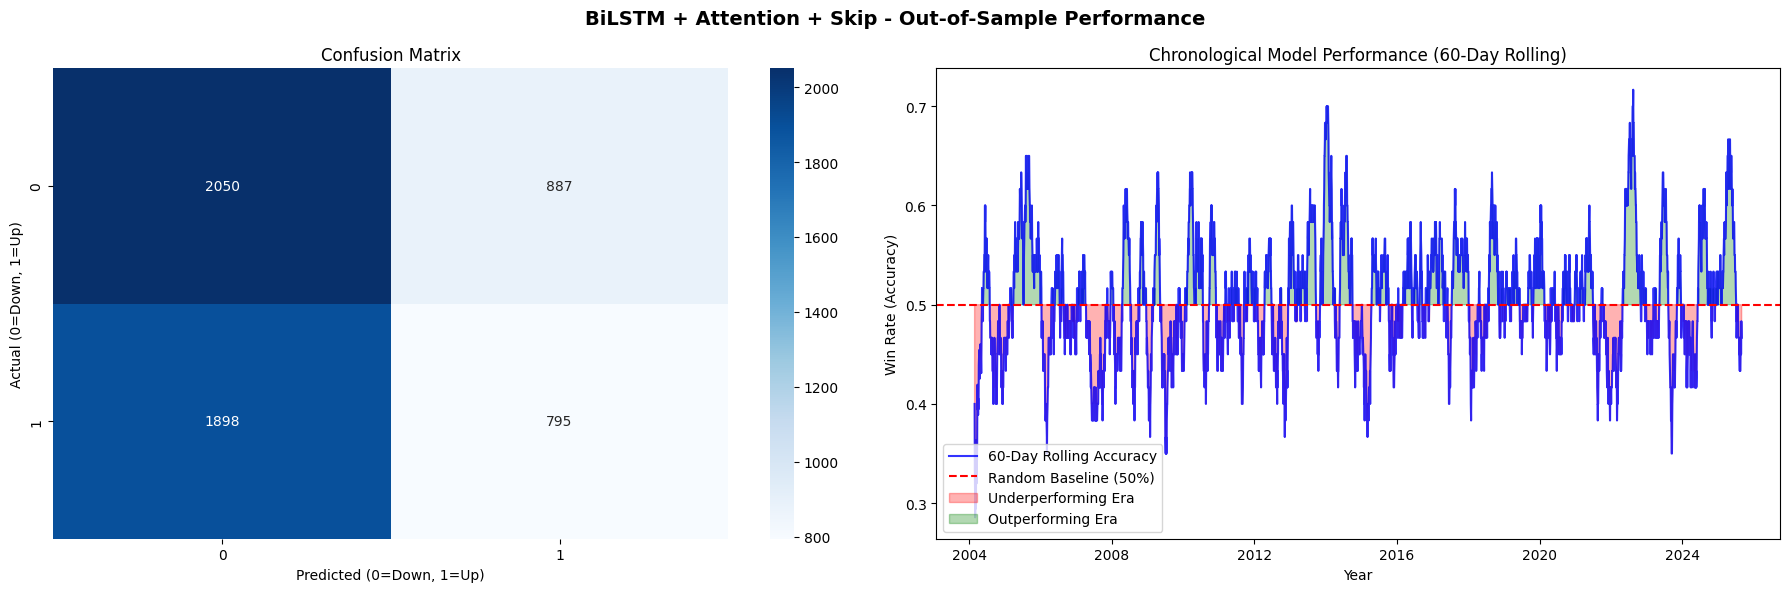

In [37]:
tscv = TimeSeriesSplit(n_splits=5)
bilstm_y_true, bilstm_y_pred, bilstm_y_prob, bilstm_indices = [], [], [], []

print("=== BiLSTM: Starting 5-Fold Evaluation ===")
for fold, (train_index, test_index) in enumerate(tscv.split(X_all)):
    X_train_fold, X_test_fold = X_all[train_index], X_all[test_index]
    y_train_fold, y_test_fold = y_all[train_index], y_all[test_index]
    current_indices = merged_df.index[LOOKBACK:][test_index]
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_fold.reshape(-1, X_train_fold.shape[2])).reshape(X_train_fold.shape)
    X_test_s = scaler.transform(X_test_fold.reshape(-1, X_test_fold.shape[2])).reshape(X_test_fold.shape)
    
    model = train_bilstm_model(X_train_s, y_train_fold, X_test_s, y_test_fold, **bilstm_best_params)
    model.eval()
    with torch.no_grad():
        preds_prob = model(torch.tensor(X_test_s, dtype=torch.float32)).squeeze().numpy()
    y_pred, acc, _, _, _, _, f1, _ = evaluate_predictions(y_test_fold, preds_prob)
    
    bilstm_y_true.extend(y_test_fold)
    bilstm_y_pred.extend(y_pred)
    bilstm_y_prob.extend(preds_prob)
    bilstm_indices.extend(current_indices)
    print(f"BiLSTM Fold {fold+1} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

plot_results(bilstm_y_true, bilstm_y_pred, bilstm_y_prob, bilstm_indices, "BiLSTM + Attention + Skip")

---
# 7. Model Comparison

Final metrics across all test folds for all optimized architectures. Precision/Recall track both directional classes (Up vs Down).

In [38]:
_, rnn_acc, rnn_p_u, rnn_p_d, rnn_r_u, rnn_r_d, rnn_f1, _ = evaluate_predictions(np.array(rnn_y_true), np.array(rnn_y_prob))
_, birnn_acc, birnn_p_u, birnn_p_d, birnn_r_u, birnn_r_d, birnn_f1, _ = evaluate_predictions(np.array(birnn_y_true), np.array(birnn_y_prob))
_, lstm_acc, lstm_p_u, lstm_p_d, lstm_r_u, lstm_r_d, lstm_f1, _ = evaluate_predictions(np.array(lstm_y_true), np.array(lstm_y_prob))
_, bilstm_acc, bilstm_p_u, bilstm_p_d, bilstm_r_u, bilstm_r_d, bilstm_f1, _ = evaluate_predictions(np.array(bilstm_y_true), np.array(bilstm_y_prob))

comparison = pd.DataFrame({
    'Model': [
        'RNN + Attention + Skip', 
        'BiRNN + Attention + Skip',
        'LSTM + Attention + Skip',
        'BiLSTM + Attention + Skip'
    ],
    'Attn': [
        rnn_best_params.get('attn_type', 'N/A'), 
        birnn_best_params.get('attn_type', 'N/A'),
        lstm_best_params.get('attn_type', 'N/A'),
        bilstm_best_params.get('attn_type', 'N/A')
    ],
    'Skip': [
        rnn_best_params.get('skip_type', 'N/A'), 
        birnn_best_params.get('skip_type', 'N/A'),
        lstm_best_params.get('skip_type', 'N/A'),
        bilstm_best_params.get('skip_type', 'N/A')
    ],
    'Dim': [
        rnn_best_params.get('hidden_dim', 'N/A'), 
        birnn_best_params.get('hidden_dim', 'N/A'),
        lstm_best_params.get('hidden_dim', 'N/A'),
        bilstm_best_params.get('hidden_dim', 'N/A')
    ],
    'L': [
        rnn_best_params.get('num_layers', 'N/A'), 
        birnn_best_params.get('num_layers', 'N/A'),
        lstm_best_params.get('num_layers', 'N/A'),
        bilstm_best_params.get('num_layers', 'N/A')
    ],
    'Drop': [
        rnn_best_params.get('dropout', 'N/A'), 
        birnn_best_params.get('dropout', 'N/A'),
        lstm_best_params.get('dropout', 'N/A'),
        bilstm_best_params.get('dropout', 'N/A')
    ],
    'LR': [
        rnn_best_params.get('lr', 'N/A'), 
        birnn_best_params.get('lr', 'N/A'),
        lstm_best_params.get('lr', 'N/A'),
        bilstm_best_params.get('lr', 'N/A')
    ],
    'WD': [
        rnn_best_params.get('weight_decay', 'N/A'), 
        birnn_best_params.get('weight_decay', 'N/A'),
        lstm_best_params.get('weight_decay', 'N/A'),
        bilstm_best_params.get('weight_decay', 'N/A')
    ],
    'Pat': [
        rnn_best_params.get('patience', 'N/A'), 
        birnn_best_params.get('patience', 'N/A'),
        lstm_best_params.get('patience', 'N/A'),
        bilstm_best_params.get('patience', 'N/A')
    ],
    'Act': [
        rnn_best_params.get('activation', 'N/A'), 
        birnn_best_params.get('activation', 'N/A'),
        lstm_best_params.get('activation', 'N/A'),
        bilstm_best_params.get('activation', 'N/A')
    ],
    'Precision (Up)': [
        f'{rnn_p_u:.4f}', f'{birnn_p_u:.4f}', f'{lstm_p_u:.4f}', f'{bilstm_p_u:.4f}'
    ],
    'Recall (Up)': [
        f'{rnn_r_u:.4f}', f'{birnn_r_u:.4f}', f'{lstm_r_u:.4f}', f'{bilstm_r_u:.4f}'
    ],
    'Precision (Dn)': [
        f'{rnn_p_d:.4f}', f'{birnn_p_d:.4f}', f'{lstm_p_d:.4f}', f'{bilstm_p_d:.4f}'
    ],
    'Recall (Dn)': [
        f'{rnn_r_d:.4f}', f'{birnn_r_d:.4f}', f'{lstm_r_d:.4f}', f'{bilstm_r_d:.4f}'
    ],
    'OOS Acc': [
        f'{rnn_acc:.4f}', f'{birnn_acc:.4f}', f'{lstm_acc:.4f}', f'{bilstm_acc:.4f}'
    ],
    'OOS F1': [
        f'{rnn_f1:.4f}', f'{birnn_f1:.4f}', f'{lstm_f1:.4f}', f'{bilstm_f1:.4f}'
    ]
})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("\n=== Final 4-Way Model Comparison (Optimized Grid & Early Stopping) ===")
print(comparison.to_string(index=False))


=== Final 4-Way Model Comparison (Optimized Grid & Early Stopping) ===
                    Model      Attn  Skip  Dim  L  Drop    LR      WD  Pat  Act Precision (Up) Recall (Up) Precision (Dn) Recall (Dn) OOS Acc OOS F1
   RNN + Attention + Skip  additive   add   64  1   0.3 0.001 0.00100   20 relu         0.4796      0.3620         0.5224      0.6398  0.5069 0.4126
 BiRNN + Attention + Skip  additive gated   64  1   0.4 0.001 0.00100   30 mish         0.4719      0.3030         0.5188      0.6891  0.5044 0.3691
  LSTM + Attention + Skip multihead gated   64  1   0.2 0.002 0.00001   10 gelu         0.4732      0.3245         0.5192      0.6687  0.5041 0.3850
BiLSTM + Attention + Skip multihead   add   48  2   0.3 0.001 0.00001   30 relu         0.4727      0.2952         0.5193      0.6980  0.5053 0.3634
